# LV2: Umrechnung von Z-Parametern in S-Parametern

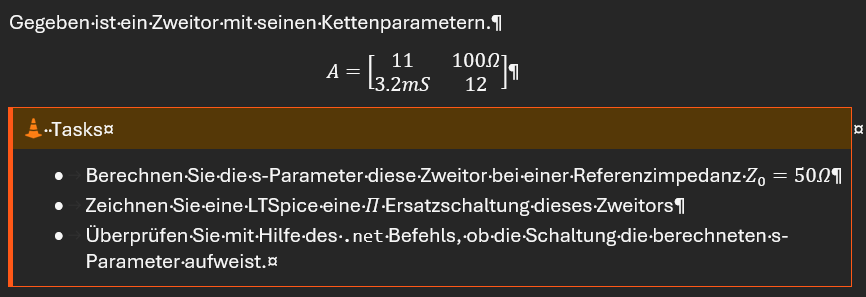

In [ ]:
import numpy as np
pi = np.pi
j = 1j
# ----------------------------------------------------------
# Von A Parameter zu Z-Parameter
# ----------------------------------------------------------
A = np.array([[11,100],[3.2e-3, 12]])

A11 = A[(0,0)]
A12 = A[(0,1)]
A21 = A[(1,0)]
A22 = A[(1,1)]

detA = np.linalg.det(A)

Z = np.array([[A11/A21, detA/A21],[1/A21, A22/A21]])
print(Z)


# ----------------------------------------------------------
# Berechnung S-Parameter bei ReferenzImpedanz Z0 = 50 Ohm
# ----------------------------------------------------------

Z0 = 50
#normalisierung Z Parameter durch Z0
z11 = Z[(0,0)]/Z0
z12 = Z[(0,1)]/Z0
z21 = Z[(1,0)]/Z0
z22 = Z[(1,1)]/Z0

# Hilfsausdruck dz
dz = (1+z11)*(1+z22)-z12*z21

#Sparameter Formeln
S11 = ((z11 - 1)*(z22 + 1)-z12*z21)/dz
S12 = (2*z12)/dz
S21 = (2*z21)/dz
S22 = ((z11 + 1)*(z22 - 1)-z12*z21)/dz

S = np.array([[S11, S12],[S21, S22]])
print(S)

# ----------------------------------------------------------
# Ausgabe von Z1, Z2 und Z3 für Pi Schaltung
# ----------------------------------------------------------

det_Z = np.linalg.det(Z)

# 2. Berechnung der Y-Parameter (Admittanz-Parameter)
# [Y] = (1/det Z) * [[Z22, -Z12], [-Z21, Z11]]
Y11 = Z[(1,1)] / det_Z
Y12 = -Z[(0,1)] / det_Z
Y21 = -Z[(1,0)] / det_Z
Y22 = Z[(0,0)] / det_Z

# 3. Berechnung der П-Ersatzschaltung Admittanzen (YA, YB, YC)
# YC (Serienelement der П-Schaltung)
YC = -Y12 
# YA (Shunt am Eingang)
YA = Y11 - YC
# YB (Shunt am Ausgang)
YB = Y22 - YC

# 4. Berechnung der П-Ersatzschaltung Impedanzen (Z1, Z2, Z3)
# Z = 1/Y
# Z1 und Z3 sind die Shunts (Querzweige), Z2 ist das Serienelement (Längszweig)
Z1_shunt_input = 1 / YA
Z2_series_middle = 1 / YC
Z3_shunt_output = 1 / YB

# ----------------------------------------------------------
print(f".param Z1 {Z1_shunt_input:.6f}")
print(f".param Z2 {Z2_series_middle:.6f}")
print(f".param Z3 {Z3_shunt_output:.6f}")


[[ 3437.5 41150. ]
 [  312.5  3750. ]]
[[ 0.03338633 10.46740859]
 [ 0.07949126  0.11287758]]
--- Berechnung der П-Ersatzschaltung Impedanzen ---
Determinante det(Z): 31250.00 Ohm^2

Berechnete Y-Parameter (Siemens):
Y11: 0.120000, Y12: -1.316800
Y21: -0.010000, Y22: 0.110000

П-Ersatzschaltung Impedanzen (Ohm):
Z1 (Shunt, Eingang, 1/YA): -0.835561 Ohm
Z2 (Serie, Mitte, 1/YC): 0.759417 Ohm
Z3 (Shunt, Ausgang, 1/YB): -0.828638 Ohm
.param Z1 -0.835561
.param Z2 0.759417
.param Z3 -0.828638
